# ==========================================================
# 62 - Final LOGO Evaluation
#
# Final Sensor-based Driver Behavior Classification
# using Leave-One-Group-Out Cross Validation
# ==========================================================

In [1]:
import sys
from pathlib import Path

PROJECT_PATH = Path("/content/drive/MyDrive/UAH_Project")
SRC = str(PROJECT_PATH / "src")

if SRC not in sys.path:
    sys.path.insert(0, SRC)

print(SRC)

/content/drive/MyDrive/UAH_Project/src


In [2]:
from google.colab import drive

drive.mount("/content/drive")

Mounted at /content/drive


In [3]:
from pathlib import Path

for p in (PROJECT_PATH / "src").iterdir():
    print(p.name)

__init__.py
utils.py
__pycache__
_sync_test.txt
config.py
preprocessor.py
data_loader.py
fusion_model.py
fusion_trainer.py
video_model.py
video_trainer.py
video_lstm_model.py
trainer.py
lstm_model.py


In [4]:
import numpy as np
import torch
import importlib

from sklearn.model_selection import LeaveOneGroupOut
from sklearn.preprocessing import StandardScaler

from sklearn.utils.class_weight import compute_class_weight

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
)

import lstm_model
import trainer

importlib.reload(lstm_model)
importlib.reload(trainer)

from lstm_model import LSTMClassifier
from trainer import (
    create_dataloader,
    fit,
)

In [7]:
from pathlib import Path

PROJECT_PATH = Path("/content/drive/MyDrive/UAH_Project")

SENSOR_DATASET = (
    PROJECT_PATH
    / "datasets"
    / "processed"
    / "uah_dataset.npz"
)

print(SENSOR_DATASET)
print(SENSOR_DATASET.exists())

/content/drive/MyDrive/UAH_Project/datasets/processed/uah_dataset.npz
True


In [8]:
sensor = np.load(SENSOR_DATASET)

X = sensor["X"]
y = sensor["y"]
groups = sensor["groups"]

print(X.shape)
print(y.shape)
print(groups.shape)

(30676, 120, 13)
(30676,)
(30676,)


In [10]:
logo = LeaveOneGroupOut()

fold_results = []

all_predictions = []
all_labels = []

fold = 1

for train_idx, test_idx in logo.split(
    X,
    y,
    groups,
):

    print("=" * 60)
    print(f"Fold {fold}")
    print("=" * 60)

    X_train = X[train_idx]
    X_test = X[test_idx]

    y_train = y[train_idx]
    y_test = y[test_idx]

    fold += 1

Fold 1
Fold 2
Fold 3
Fold 4
Fold 5
Fold 6
Fold 7
Fold 8
Fold 9
Fold 10
Fold 11
Fold 12
Fold 13
Fold 14
Fold 15
Fold 16
Fold 17
Fold 18
Fold 19
Fold 20
Fold 21
Fold 22
Fold 23
Fold 24
Fold 25
Fold 26
Fold 27
Fold 28
Fold 29
Fold 30
Fold 31
Fold 32
Fold 33
Fold 34
Fold 35
Fold 36
Fold 37
Fold 38
Fold 39
Fold 40


In [12]:
logo = LeaveOneGroupOut()

logo_iterator = logo.split(
    X,
    y,
    groups,
)

train_idx, test_idx = next(logo_iterator)

print(len(train_idx))
print(len(test_idx))

30070
606


In [13]:
X_train = X[train_idx]
X_test = X[test_idx]

y_train = y[train_idx]
y_test = y[test_idx]

print(X_train.shape)
print(X_test.shape)

print(y_train.shape)
print(y_test.shape)

(30070, 120, 13)
(606, 120, 13)
(30070,)
(606,)


In [14]:
scaler = StandardScaler()

X_train_flat = X_train.reshape(-1, X_train.shape[-1])
X_test_flat = X_test.reshape(-1, X_test.shape[-1])

scaler.fit(X_train_flat)

X_train = scaler.transform(X_train_flat).reshape(X_train.shape)
X_test = scaler.transform(X_test_flat).reshape(X_test.shape)

print(X_train.shape)
print(X_test.shape)

(30070, 120, 13)
(606, 120, 13)


In [16]:
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print(device)

cpu


In [17]:
classes = np.unique(y_train)

class_weights = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=y_train,
)

weights = torch.FloatTensor(class_weights).to(device)

print(class_weights)

[0.80931234 1.0180107  1.27864949]


In [18]:
train_loader = create_dataloader(
    X_train,
    y_train,
    batch_size=32,
    shuffle=True,
)

test_loader = create_dataloader(
    X_test,
    y_test,
    batch_size=32,
    shuffle=False,
)

print(len(train_loader))
print(len(test_loader))

940
19


In [19]:
model = LSTMClassifier().to(device)

print(model)

LSTMClassifier(
  (lstm): LSTM(13, 64, num_layers=2, batch_first=True, dropout=0.3)
  (classifier): Sequential(
    (0): Linear(in_features=64, out_features=32, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=32, out_features=3, bias=True)
  )
)


In [20]:
criterion = torch.nn.CrossEntropyLoss(
    weight=weights,
)

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=1e-4,
)

In [21]:
EPOCHS = 20
PATIENCE = 3

In [22]:
history = fit(
    model=model,
    train_loader=train_loader,
    val_loader=test_loader,
    criterion=criterion,
    optimizer=optimizer,
    device=device,
    epochs=EPOCHS,
    patience=PATIENCE,
)

Epoch 1/20 | Train Loss: 0.9295 | Train Acc: 0.4859 | Val Loss: 0.9703 | Val Acc: 0.7079
Epoch 2/20 | Train Loss: 0.7211 | Train Acc: 0.6416 | Val Loss: 1.1143 | Val Acc: 0.6518
Epoch 3/20 | Train Loss: 0.6567 | Train Acc: 0.6755 | Val Loss: 1.0713 | Val Acc: 0.5957
Epoch 4/20 | Train Loss: 0.6177 | Train Acc: 0.6900 | Val Loss: 1.3957 | Val Acc: 0.5759

Early stopping at epoch 4
Best Validation Accuracy : 0.7079


In [23]:
model.eval()

y_true = []
y_pred = []

with torch.no_grad():

    for sensor_batch, label_batch in test_loader:

        sensor_batch = sensor_batch.to(device)

        outputs = model(sensor_batch)

        preds = outputs.argmax(dim=1)

        y_true.extend(label_batch.numpy())
        y_pred.extend(preds.cpu().numpy())

In [24]:
print("Accuracy :", accuracy_score(y_true, y_pred))
print()

print(
    classification_report(
        y_true,
        y_pred,
        target_names=[
            "NORMAL",
            "DROWSY",
            "AGGRESSIVE",
        ],
    )
)

Accuracy : 0.7079207920792079

              precision    recall  f1-score   support

      NORMAL       1.00      0.71      0.83       606
      DROWSY       0.00      0.00      0.00         0
  AGGRESSIVE       0.00      0.00      0.00         0

    accuracy                           0.71       606
   macro avg       0.33      0.24      0.28       606
weighted avg       1.00      0.71      0.83       606



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [25]:
fold_accuracies = []
fold_f1_scores = []

all_labels = []
all_predictions = []

In [26]:
logo = LeaveOneGroupOut()

for fold, (train_idx, test_idx) in enumerate(
    logo.split(X, y, groups),
    start=1,
):

    print("=" * 60)
    print(f"Fold {fold}/40")
    print("=" * 60)

    X_train = X[train_idx]
    X_test = X[test_idx]

    y_train = y[train_idx]
    y_test = y[test_idx]

Fold 1/40
Fold 2/40
Fold 3/40
Fold 4/40
Fold 5/40
Fold 6/40
Fold 7/40
Fold 8/40
Fold 9/40
Fold 10/40
Fold 11/40
Fold 12/40
Fold 13/40
Fold 14/40
Fold 15/40
Fold 16/40
Fold 17/40
Fold 18/40
Fold 19/40
Fold 20/40
Fold 21/40
Fold 22/40
Fold 23/40
Fold 24/40
Fold 25/40
Fold 26/40
Fold 27/40
Fold 28/40
Fold 29/40
Fold 30/40
Fold 31/40
Fold 32/40
Fold 33/40
Fold 34/40
Fold 35/40
Fold 36/40
Fold 37/40
Fold 38/40
Fold 39/40
Fold 40/40


In [27]:
    scaler = StandardScaler()

    X_train_flat = X_train.reshape(-1, X_train.shape[-1])
    X_test_flat = X_test.reshape(-1, X_test.shape[-1])

    scaler.fit(X_train_flat)

    X_train = scaler.transform(X_train_flat).reshape(X_train.shape)
    X_test = scaler.transform(X_test_flat).reshape(X_test.shape)

In [28]:
    classes = np.unique(y_train)

    class_weights = compute_class_weight(
        class_weight="balanced",
        classes=classes,
        y=y_train,
    )

    weights = torch.FloatTensor(class_weights).to(device)

In [29]:
logo = LeaveOneGroupOut()

fold_accuracies = []
fold_f1_scores = []

all_labels = []
all_predictions = []

for fold, (train_idx, test_idx) in enumerate(
    logo.split(X, y, groups),
    start=1,
):

    print("=" * 60)
    print(f"Fold {fold}/40")
    print("=" * 60)

    # --------------------------------------------------
    # Split
    # --------------------------------------------------

    X_train = X[train_idx]
    X_test = X[test_idx]

    y_train = y[train_idx]
    y_test = y[test_idx]

    # --------------------------------------------------
    # StandardScaler
    # --------------------------------------------------

    scaler = StandardScaler()

    X_train_flat = X_train.reshape(-1, X_train.shape[-1])
    X_test_flat = X_test.reshape(-1, X_test.shape[-1])

    scaler.fit(X_train_flat)

    X_train = scaler.transform(X_train_flat).reshape(X_train.shape)
    X_test = scaler.transform(X_test_flat).reshape(X_test.shape)

    # --------------------------------------------------
    # Class Weights
    # --------------------------------------------------

    classes = np.unique(y_train)

    class_weights = compute_class_weight(
        class_weight="balanced",
        classes=classes,
        y=y_train,
    )

    weights = torch.FloatTensor(class_weights).to(device)

    # --------------------------------------------------
    # DataLoader
    # --------------------------------------------------

    train_loader = create_dataloader(
        X_train,
        y_train,
        batch_size=32,
        shuffle=True,
    )

    test_loader = create_dataloader(
        X_test,
        y_test,
        batch_size=32,
        shuffle=False,
    )

    # --------------------------------------------------
    # Model
    # --------------------------------------------------

    model = LSTMClassifier().to(device)

    criterion = torch.nn.CrossEntropyLoss(
        weight=weights,
    )

    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=1e-4,
    )

    history = fit(
        model=model,
        train_loader=train_loader,
        val_loader=test_loader,
        criterion=criterion,
        optimizer=optimizer,
        device=device,
        epochs=20,
        patience=3,
    )

    # --------------------------------------------------
    # Prediction
    # --------------------------------------------------

    model.eval()

    fold_labels = []
    fold_preds = []

    with torch.no_grad():

        for sensor_batch, label_batch in test_loader:

            sensor_batch = sensor_batch.to(device)

            outputs = model(sensor_batch)

            preds = outputs.argmax(dim=1)

            fold_labels.extend(label_batch.numpy())
            fold_preds.extend(preds.cpu().numpy())

    # --------------------------------------------------
    # Metrics
    # --------------------------------------------------

    fold_acc = accuracy_score(
        fold_labels,
        fold_preds,
    )

    fold_f1 = f1_score(
        fold_labels,
        fold_preds,
        average="weighted",
        zero_division=0,
    )

    print(f"Accuracy : {fold_acc:.4f}")
    print(f"F1 Score : {fold_f1:.4f}")
    print()

    fold_accuracies.append(fold_acc)
    fold_f1_scores.append(fold_f1)

    all_labels.extend(fold_labels)
    all_predictions.extend(fold_preds)

Fold 1/40
Epoch 1/20 | Train Loss: 0.8970 | Train Acc: 0.5225 | Val Loss: 1.3433 | Val Acc: 0.5182
Epoch 2/20 | Train Loss: 0.7049 | Train Acc: 0.6783 | Val Loss: 1.2607 | Val Acc: 0.6007
Epoch 3/20 | Train Loss: 0.6347 | Train Acc: 0.7308 | Val Loss: 1.2563 | Val Acc: 0.5495
Epoch 4/20 | Train Loss: 0.6063 | Train Acc: 0.7454 | Val Loss: 1.1928 | Val Acc: 0.6386
Epoch 5/20 | Train Loss: 0.5742 | Train Acc: 0.7561 | Val Loss: 2.2355 | Val Acc: 0.4158
Epoch 6/20 | Train Loss: 0.5490 | Train Acc: 0.7681 | Val Loss: 2.1506 | Val Acc: 0.4059
Epoch 7/20 | Train Loss: 0.5235 | Train Acc: 0.7745 | Val Loss: 1.4109 | Val Acc: 0.5446

Early stopping at epoch 7
Best Validation Accuracy : 0.6386
Accuracy : 0.6386
F1 Score : 0.7795

Fold 2/40
Epoch 1/20 | Train Loss: 0.9118 | Train Acc: 0.4873 | Val Loss: 0.9794 | Val Acc: 0.0016
Epoch 2/20 | Train Loss: 0.6942 | Train Acc: 0.6526 | Val Loss: 1.1564 | Val Acc: 0.0343
Epoch 3/20 | Train Loss: 0.6210 | Train Acc: 0.6907 | Val Loss: 1.5514 | Val Acc:

In [30]:
print("=" * 70)
print("FINAL RESULTS")
print("=" * 70)

print(f"Mean Accuracy : {np.mean(fold_accuracies):.4f}")
print(f"Std Accuracy  : {np.std(fold_accuracies):.4f}")

print()

print(f"Mean F1 Score : {np.mean(fold_f1_scores):.4f}")
print(f"Std F1 Score  : {np.std(fold_f1_scores):.4f}")

FINAL RESULTS
Mean Accuracy : 0.7189
Std Accuracy  : 0.2236

Mean F1 Score : 0.8137
Std F1 Score  : 0.1781


In [31]:
print(
    classification_report(
        all_labels,
        all_predictions,
        target_names=[
            "NORMAL",
            "DROWSY",
            "AGGRESSIVE",
        ],
        zero_division=0,
    )
)

              precision    recall  f1-score   support

      NORMAL       0.72      0.66      0.69     12991
      DROWSY       0.65      0.66      0.66      9846
  AGGRESSIVE       0.71      0.79      0.75      7839

    accuracy                           0.70     30676
   macro avg       0.70      0.71      0.70     30676
weighted avg       0.70      0.70      0.70     30676



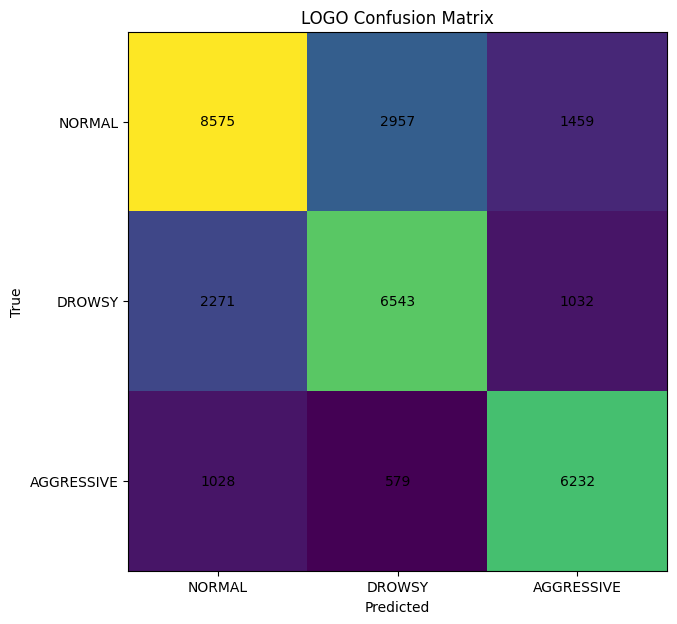

In [33]:
import matplotlib.pyplot as plt

cm = confusion_matrix(
    all_labels,
    all_predictions,
)

plt.figure(figsize=(7,7))

plt.imshow(cm)

plt.xticks(
    [0,1,2],
    ["NORMAL","DROWSY","AGGRESSIVE"]
)

plt.yticks(
    [0,1,2],
    ["NORMAL","DROWSY","AGGRESSIVE"]
)

for i in range(3):
    for j in range(3):
        plt.text(
            j,
            i,
            cm[i, j],
            ha="center",
            va="center",
        )

plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("LOGO Confusion Matrix")

plt.show()

In [34]:
print(np.unique(groups))
print(len(np.unique(groups)))

[ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23
 24 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39]
40


In [35]:
print(groups[:30])

[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]


In [36]:
for i, acc in enumerate(fold_accuracies, start=1):
    print(f"Trip {i:2d}: {acc:.4f}")

Trip  1: 0.6386
Trip  2: 0.0733
Trip  3: 0.7485
Trip  4: 0.8759
Trip  5: 0.6688
Trip  6: 0.8615
Trip  7: 0.9143
Trip  8: 0.5187
Trip  9: 0.7713
Trip 10: 0.3323
Trip 11: 0.9844
Trip 12: 0.7170
Trip 13: 0.9868
Trip 14: 0.4648
Trip 15: 0.6198
Trip 16: 0.6836
Trip 17: 0.9549
Trip 18: 0.4429
Trip 19: 0.7451
Trip 20: 0.9892
Trip 21: 0.4721
Trip 22: 0.8120
Trip 23: 0.7732
Trip 24: 0.7400
Trip 25: 0.9793
Trip 26: 0.5427
Trip 27: 0.8625
Trip 28: 0.5517
Trip 29: 0.4884
Trip 30: 0.9222
Trip 31: 0.4075
Trip 32: 0.9274
Trip 33: 0.8135
Trip 34: 0.9709
Trip 35: 0.9811
Trip 36: 0.3857
Trip 37: 0.5071
Trip 38: 0.9791
Trip 39: 0.9506
Trip 40: 0.6980


In [37]:
import numpy as np

best_trip = np.argmax(fold_accuracies)
worst_trip = np.argmin(fold_accuracies)

print("Best Trip :", best_trip)
print("Accuracy  :", fold_accuracies[best_trip])

print()

print("Worst Trip :", worst_trip)
print("Accuracy   :", fold_accuracies[worst_trip])

Best Trip : 19
Accuracy  : 0.989247311827957

Worst Trip : 1
Accuracy   : 0.07332293291731669


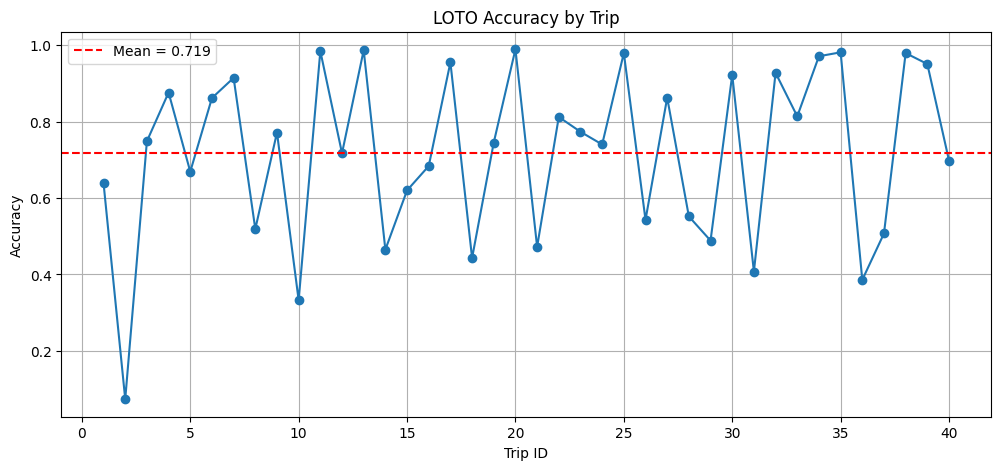

In [38]:
plt.figure(figsize=(12,5))

plt.plot(
    range(1,41),
    fold_accuracies,
    marker="o",
)

plt.axhline(
    np.mean(fold_accuracies),
    color="red",
    linestyle="--",
    label=f"Mean = {np.mean(fold_accuracies):.3f}",
)

plt.xlabel("Trip ID")
plt.ylabel("Accuracy")
plt.title("LOTO Accuracy by Trip")

plt.grid(True)
plt.legend()

plt.show()

In [39]:
trip_labels = []

for trip in range(40):
    idx = np.where(groups == trip)[0][0]
    trip_labels.append(y[idx])

label_map = {
    0: "NORMAL",
    1: "DROWSY",
    2: "AGGRESSIVE"
}

for trip, acc, label in zip(range(40), fold_accuracies, trip_labels):
    print(
        f"Trip {trip+1:2d} | "
        f"{label_map[label]:10s} | "
        f"Accuracy = {acc:.4f}"
    )

Trip  1 | NORMAL     | Accuracy = 0.6386
Trip  2 | NORMAL     | Accuracy = 0.0733
Trip  3 | NORMAL     | Accuracy = 0.7485
Trip  4 | AGGRESSIVE | Accuracy = 0.8759
Trip  5 | DROWSY     | Accuracy = 0.6688
Trip  6 | AGGRESSIVE | Accuracy = 0.8615
Trip  7 | DROWSY     | Accuracy = 0.9143
Trip  8 | NORMAL     | Accuracy = 0.5187
Trip  9 | AGGRESSIVE | Accuracy = 0.7713
Trip 10 | DROWSY     | Accuracy = 0.3323
Trip 11 | NORMAL     | Accuracy = 0.9844
Trip 12 | NORMAL     | Accuracy = 0.7170
Trip 13 | AGGRESSIVE | Accuracy = 0.9868
Trip 14 | DROWSY     | Accuracy = 0.4648
Trip 15 | NORMAL     | Accuracy = 0.6198
Trip 16 | DROWSY     | Accuracy = 0.6836
Trip 17 | NORMAL     | Accuracy = 0.9549
Trip 18 | NORMAL     | Accuracy = 0.4429
Trip 19 | AGGRESSIVE | Accuracy = 0.7451
Trip 20 | DROWSY     | Accuracy = 0.9892
Trip 21 | AGGRESSIVE | Accuracy = 0.4721
Trip 22 | NORMAL     | Accuracy = 0.8120
Trip 23 | NORMAL     | Accuracy = 0.7732
Trip 24 | AGGRESSIVE | Accuracy = 0.7400
Trip 25 | DROWSY

In [40]:
import pandas as pd

results = pd.DataFrame({
    "Trip": np.arange(1,41),
    "Behavior": [label_map[l] for l in trip_labels],
    "Accuracy": fold_accuracies,
})

results = results.sort_values("Accuracy")

results

,Trip,Behavior,Accuracy
1,2,NORMAL,0.073323
9,10,DROWSY,0.332255
35,36,NORMAL,0.385686
30,31,DROWSY,0.407477
17,18,NORMAL,0.442922
13,14,DROWSY,0.464789
20,21,AGGRESSIVE,0.472087
28,29,NORMAL,0.488423
36,37,DROWSY,0.507109
7,8,NORMAL,0.518681


In [41]:
from pathlib import Path

VIDEO_PATH = (
    Path("/content/drive/MyDrive/UAH_Project")
    / "datasets"
    / "raw"
    / "UAH-DRIVESET-v1"
)

video_paths = sorted(VIDEO_PATH.rglob("*.mp4"))

print(len(video_paths))

for i, p in enumerate(video_paths[:5]):
    print(i, p.name)

40
0 20151110175712-16km-D1-NORMAL1-SECONDARY.mp4
1 20151110180846-16km-D1-NORMAL2-SECONDARY.mp4
2 20151111123123-25km-D1-NORMAL-MOTORWAY.mp4
3 20151111125204-24km-D1-AGGRESSIVE-MOTORWAY.mp4
4 20151111132343-25km-D1-DROWSY-MOTORWAY.mp4


In [42]:
video_names = [p.stem for p in video_paths]

analysis = pd.DataFrame({
    "Trip": np.arange(1, 41),
    "Video": video_names,
    "Behavior": [label_map[l] for l in trip_labels],
    "Accuracy": fold_accuracies,
})

analysis = analysis.sort_values("Accuracy")

analysis

,Trip,Video,Behavior,Accuracy
1,2,20151110180846-16km-D1-NORMAL2-SECONDARY,NORMAL,0.073323
9,10,20151120135150-25km-D2-DROWSY-MOTORWAY,DROWSY,0.332255
35,36,20151217162706-26km-D6-NORMAL-MOTORWAY,NORMAL,0.385686
30,31,20151211160230-25km-D5-DROWSY-MOTORWAY,DROWSY,0.407477
17,18,20151126125500-16km-D3-NORMAL2-SECONDARY,NORMAL,0.442922
13,14,20151120165604-16km-D2-DROWSY-SECONDARY,DROWSY,0.464789
20,21,20151126134731-26km-D3-AGGRESSIVE-MOTORWAY,AGGRESSIVE,0.472087
28,29,20151209151237-25km-D5-NORMAL-MOTORWAY,NORMAL,0.488423
36,37,20151217164653-25km-D6-DROWSY-MOTORWAY,DROWSY,0.507109
7,8,20151120131704-26km-D2-NORMAL-MOTORWAY,NORMAL,0.518681


In [43]:
analysis["Driver"] = analysis["Video"].str.extract(r"(D\d)")
analysis["Road"] = analysis["Video"].str.extract(
    r"(MOTORWAY|SECONDARY)"
)

analysis

,Trip,Video,Behavior,Accuracy,Driver,Road
1,2,20151110180846-16km-D1-NORMAL2-SECONDARY,NORMAL,0.073323,D1,SECONDARY
9,10,20151120135150-25km-D2-DROWSY-MOTORWAY,DROWSY,0.332255,D2,MOTORWAY
35,36,20151217162706-26km-D6-NORMAL-MOTORWAY,NORMAL,0.385686,D6,MOTORWAY
30,31,20151211160230-25km-D5-DROWSY-MOTORWAY,DROWSY,0.407477,D5,MOTORWAY
17,18,20151126125500-16km-D3-NORMAL2-SECONDARY,NORMAL,0.442922,D3,SECONDARY
13,14,20151120165604-16km-D2-DROWSY-SECONDARY,DROWSY,0.464789,D2,SECONDARY
20,21,20151126134731-26km-D3-AGGRESSIVE-MOTORWAY,AGGRESSIVE,0.472087,D3,MOTORWAY
28,29,20151209151237-25km-D5-NORMAL-MOTORWAY,NORMAL,0.488423,D5,MOTORWAY
36,37,20151217164653-25km-D6-DROWSY-MOTORWAY,DROWSY,0.507109,D6,MOTORWAY
7,8,20151120131704-26km-D2-NORMAL-MOTORWAY,NORMAL,0.518681,D2,MOTORWAY


In [44]:
analysis.groupby("Driver")["Accuracy"].mean().sort_values()

,Accuracy
Driver,
D2,0.682169
D1,0.682998
D3,0.701101
D6,0.704097
D4,0.751618
D5,0.787291


In [45]:
analysis.groupby("Road")["Accuracy"].mean()

,Accuracy
Road,
MOTORWAY,0.614259
SECONDARY,0.804549


In [46]:
analysis.groupby("Behavior")["Accuracy"].mean()

,Accuracy
Behavior,
AGGRESSIVE,0.809658
DROWSY,0.702520
NORMAL,0.671779


In [47]:
analysis.groupby(
    ["Driver", "Road", "Behavior"]
)["Accuracy"].mean().sort_values()

,,,Accuracy
Driver,Road,Behavior,
D2,MOTORWAY,DROWSY,0.332255
D1,SECONDARY,NORMAL,0.355968
D6,MOTORWAY,NORMAL,0.385686
D5,MOTORWAY,DROWSY,0.407477
D2,SECONDARY,DROWSY,0.464789
D3,MOTORWAY,AGGRESSIVE,0.472087
D5,MOTORWAY,NORMAL,0.488423
D6,MOTORWAY,DROWSY,0.507109
D2,MOTORWAY,NORMAL,0.518681


<Figure size 800x500 with 0 Axes>

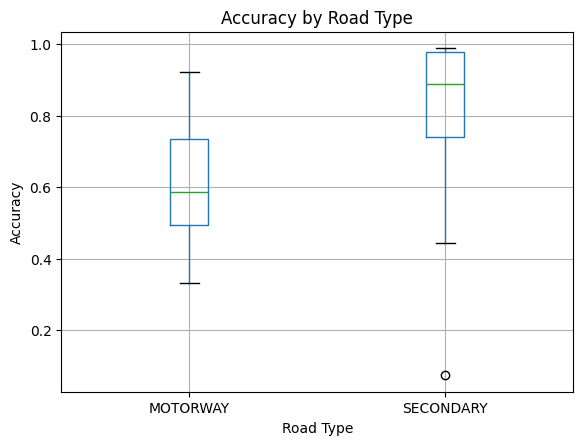

In [48]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

analysis.boxplot(
    column="Accuracy",
    by="Road"
)

plt.title("Accuracy by Road Type")
plt.suptitle("")
plt.xlabel("Road Type")
plt.ylabel("Accuracy")

plt.show()

<Figure size 800x500 with 0 Axes>

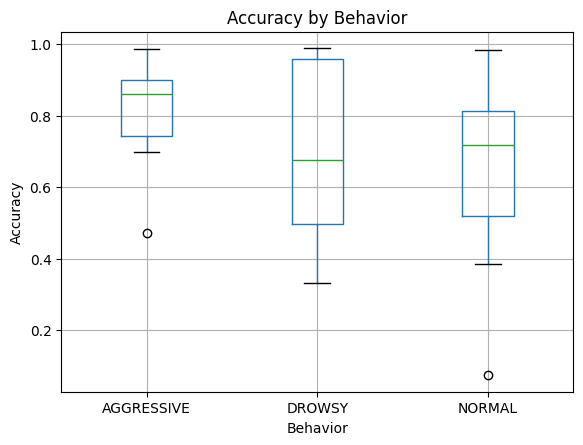

In [49]:
plt.figure(figsize=(8,5))

analysis.boxplot(
    column="Accuracy",
    by="Behavior"
)

plt.title("Accuracy by Behavior")
plt.suptitle("")
plt.xlabel("Behavior")
plt.ylabel("Accuracy")

plt.show()

In [50]:
problem_trip = 1   # Trip 2 (0-based index)

problem_idx = np.where(groups == problem_trip)[0]

print("Video:")
print(analysis.loc[analysis["Trip"] == 2, "Video"].values[0])

print()

print("Window Count:", len(problem_idx))
print("True Label :", label_map[y[problem_idx[0]]])

Video:
20151110180846-16km-D1-NORMAL2-SECONDARY

Window Count: 641
True Label : NORMAL


In [51]:
window_counts = []

for trip in range(40):
    window_counts.append(np.sum(groups == trip))

window_df = pd.DataFrame({
    "Trip": np.arange(1,41),
    "Windows": window_counts,
    "Accuracy": fold_accuracies
})

window_df.sort_values("Windows")

,Trip,Windows,Accuracy
33,34,412,0.970874
6,7,490,0.914286
5,6,520,0.861538
12,13,605,0.986777
0,1,606,0.638614
10,11,639,0.984351
13,14,639,0.464789
1,2,641,0.073323
23,24,650,0.740000
19,20,651,0.989247


In [52]:
problem_X = X[problem_idx]

print(problem_X.shape)

print("NaN:", np.isnan(problem_X).sum())

print("Inf:", np.isinf(problem_X).sum())

(641, 120, 13)
NaN: 0
Inf: 0


In [53]:
feature_mean = problem_X.mean(axis=(0,1))
feature_std = problem_X.std(axis=(0,1))

for i in range(13):
    print(
        f"Feature {i:2d} | "
        f"mean={feature_mean[i]:8.3f} | "
        f"std={feature_std[i]:8.3f}"
    )

Feature  0 | mean=  -0.012 | std=   0.033
Feature  1 | mean=   0.000 | std=   0.036
Feature  2 | mean=  -0.004 | std=   0.024
Feature  3 | mean=  -1.562 | std=   0.035
Feature  4 | mean=  -0.015 | std=   0.057
Feature  5 | mean=  -1.723 | std=   0.872
Feature  6 | mean=  91.649 | std=   7.194
Feature  7 | mean= 118.954 | std=  26.591
Feature  8 | mean=  -0.117 | std=   1.810
Feature  9 | mean=  -0.314 | std=   1.757
Feature 10 | mean=  11.017 | std=  13.112
Feature 11 | mean=  -0.037 | std=   0.971
Feature 12 | mean=   0.551 | std=   0.549


In [54]:
from collections import Counter

problem_dataset = create_dataloader(
    X[problem_idx],
    y[problem_idx],
    batch_size=32,
    shuffle=False,
)

model.eval()

preds = []

with torch.no_grad():

    for sensor_batch, label_batch in problem_dataset:

        sensor_batch = sensor_batch.to(device)

        outputs = model(sensor_batch)

        pred = outputs.argmax(dim=1)

        preds.extend(pred.cpu().numpy())

print("True Label :", label_map[y[problem_idx][0]])

print()

print(Counter(preds))

True Label : NORMAL

Counter({np.int64(2): 614, np.int64(0): 27})


In [55]:
problem_trip = 1      # Trip 2
normal_trip = 31      # Trip 32
aggressive_trip = 12  # Trip 13

problem_X = X[groups == problem_trip]
normal_X = X[groups == normal_trip]
aggressive_X = X[groups == aggressive_trip]

print(problem_X.shape)
print(normal_X.shape)
print(aggressive_X.shape)

(641, 120, 13)
(689, 120, 13)
(605, 120, 13)


In [56]:
problem_mean = problem_X.mean(axis=(0,1))
normal_mean = normal_X.mean(axis=(0,1))
aggressive_mean = aggressive_X.mean(axis=(0,1))

In [57]:
feature_names = [
    "acc_x",
    "acc_y",
    "acc_z",
    "roll",
    "pitch",
    "yaw",
    "speed",
    "lane_offset",
    "front_distance",
    "relative_speed",
    "heading",
    "vehicle_state",
    "acc_resultant",
]

In [58]:
comparison = pd.DataFrame({
    "Feature": feature_names,
    "Problem_NORMAL": problem_mean,
    "Best_NORMAL": normal_mean,
    "Best_AGGRESSIVE": aggressive_mean,
})

comparison

,Feature,Problem_NORMAL,Best_NORMAL,Best_AGGRESSIVE
0,acc_x,-0.012354,-0.012210,-0.013401
1,acc_y,0.000262,0.000130,-0.000851
2,acc_z,-0.004141,-0.001132,-0.002950
3,roll,-1.561862,-1.554262,-1.545494
4,pitch,-0.015047,-0.007652,-0.008091
5,yaw,-1.723445,-0.698780,-0.827425
6,speed,91.649063,85.225959,96.217193
7,lane_offset,118.953684,300.990175,301.526716
8,front_distance,-0.117369,-0.411754,-0.388055
9,relative_speed,-0.314175,-0.168291,-0.118227


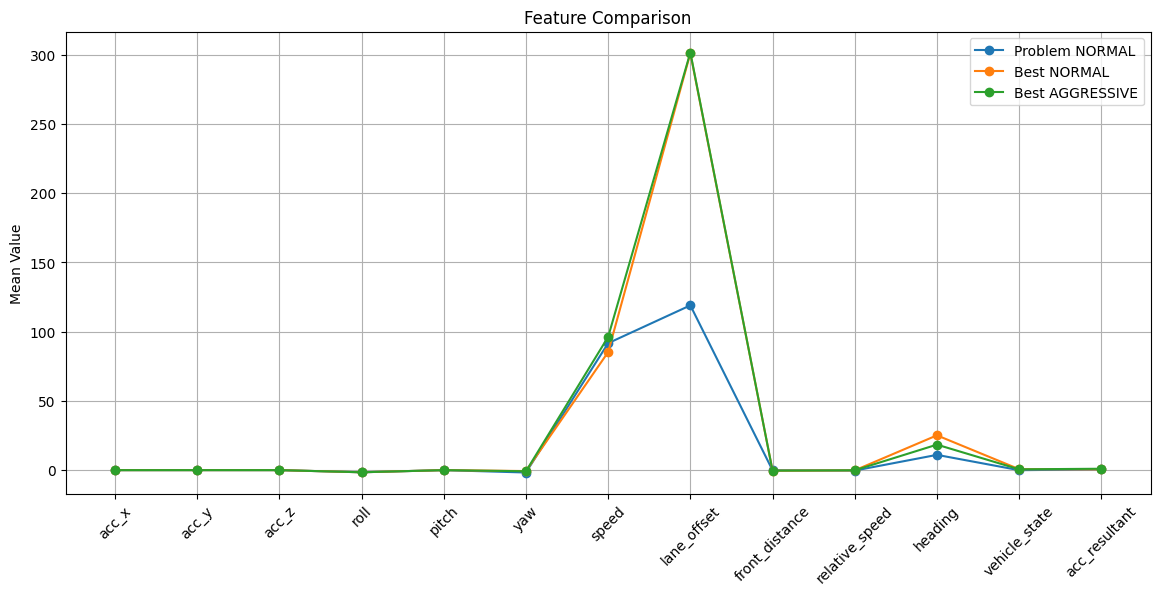

In [59]:
plt.figure(figsize=(14,6))

x = np.arange(len(feature_names))

plt.plot(
    x,
    problem_mean,
    marker="o",
    label="Problem NORMAL",
)

plt.plot(
    x,
    normal_mean,
    marker="o",
    label="Best NORMAL",
)

plt.plot(
    x,
    aggressive_mean,
    marker="o",
    label="Best AGGRESSIVE",
)

plt.xticks(
    x,
    feature_names,
    rotation=45,
)

plt.ylabel("Mean Value")
plt.title("Feature Comparison")

plt.grid(True)
plt.legend()

plt.show()

In [60]:
problem_std = problem_X.std(axis=(0,1))
normal_std = normal_X.std(axis=(0,1))
aggressive_std = aggressive_X.std(axis=(0,1))

In [61]:
comparison_std = pd.DataFrame({
    "Feature": feature_names,
    "Problem_NORMAL": problem_std,
    "Best_NORMAL": normal_std,
    "Best_AGGRESSIVE": aggressive_std,
})

comparison_std

,Feature,Problem_NORMAL,Best_NORMAL,Best_AGGRESSIVE
0,acc_x,0.032552,0.032709,0.035098
1,acc_y,0.035721,0.021322,0.027936
2,acc_z,0.024366,0.021202,0.046536
3,roll,0.034999,0.031142,0.049357
4,pitch,0.056865,0.030278,0.039058
5,yaw,0.871944,0.671788,0.785384
6,speed,7.194038,6.217130,12.637381
7,lane_offset,26.591371,26.491126,26.938101
8,front_distance,1.809849,1.295362,1.140191
9,relative_speed,1.757465,1.305411,1.155624


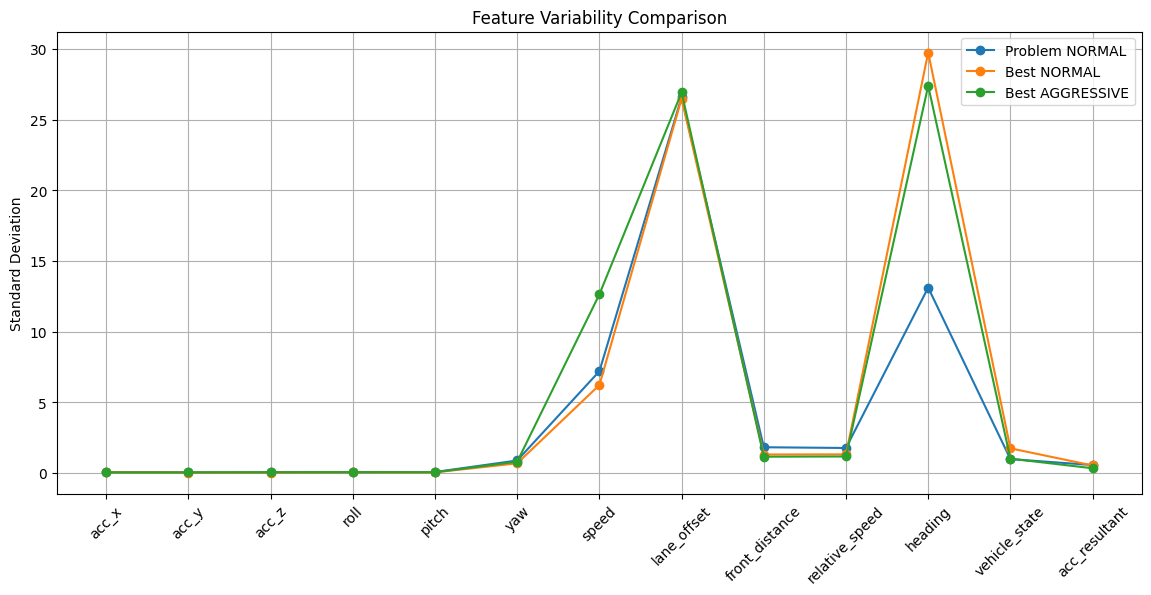

In [62]:
plt.figure(figsize=(14,6))

x = np.arange(len(feature_names))

plt.plot(
    x,
    problem_std,
    marker="o",
    label="Problem NORMAL",
)

plt.plot(
    x,
    normal_std,
    marker="o",
    label="Best NORMAL",
)

plt.plot(
    x,
    aggressive_std,
    marker="o",
    label="Best AGGRESSIVE",
)

plt.xticks(
    x,
    feature_names,
    rotation=45,
)

plt.ylabel("Standard Deviation")
plt.title("Feature Variability Comparison")

plt.grid(True)
plt.legend()

plt.show()

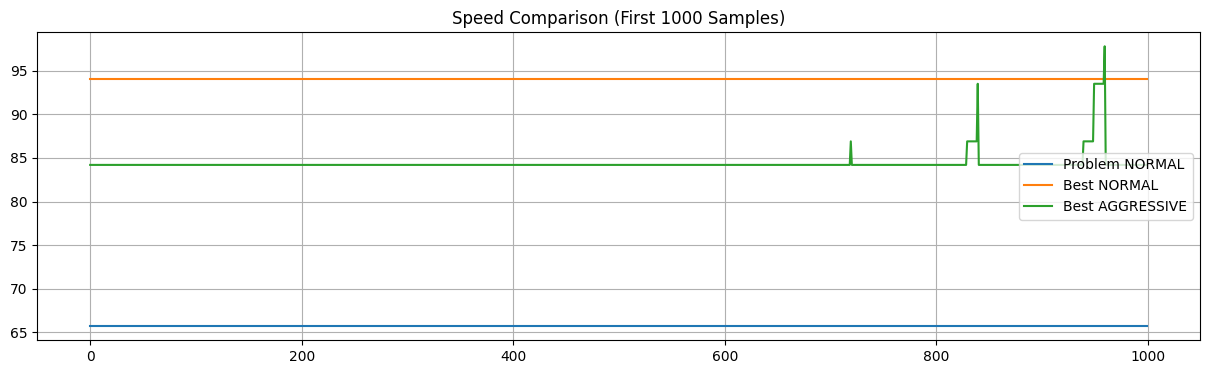

In [63]:
plt.figure(figsize=(15,4))

plt.plot(
    problem_X[:,:,6].reshape(-1)[:1000],
    label="Problem NORMAL"
)

plt.plot(
    normal_X[:,:,6].reshape(-1)[:1000],
    label="Best NORMAL"
)

plt.plot(
    aggressive_X[:,:,6].reshape(-1)[:1000],
    label="Best AGGRESSIVE"
)

plt.legend()

plt.grid(True)

plt.title("Speed Comparison (First 1000 Samples)")
plt.show()

In [64]:
speed = problem_X[:,:,6]

print(speed.shape)

print(speed[0,:10])
print(speed[1,:10])
print(speed[2,:10])

(641, 120)
[65.7 65.7 65.7 65.7 65.7 65.7 65.7 65.7 65.7 65.7]
[65.7 65.7 65.7 65.7 65.7 65.7 65.7 65.7 65.7 65.7]
[65.7 65.7 65.7 65.7 65.7 65.7 65.7 65.7 65.7 65.7]


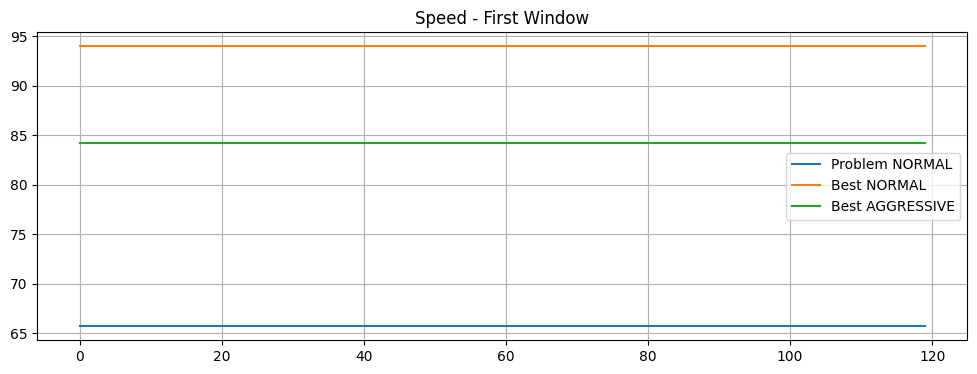

In [65]:
plt.figure(figsize=(12,4))

plt.plot(problem_X[0,:,6], label="Problem NORMAL")
plt.plot(normal_X[0,:,6], label="Best NORMAL")
plt.plot(aggressive_X[0,:,6], label="Best AGGRESSIVE")

plt.legend()
plt.grid(True)
plt.title("Speed - First Window")
plt.show()

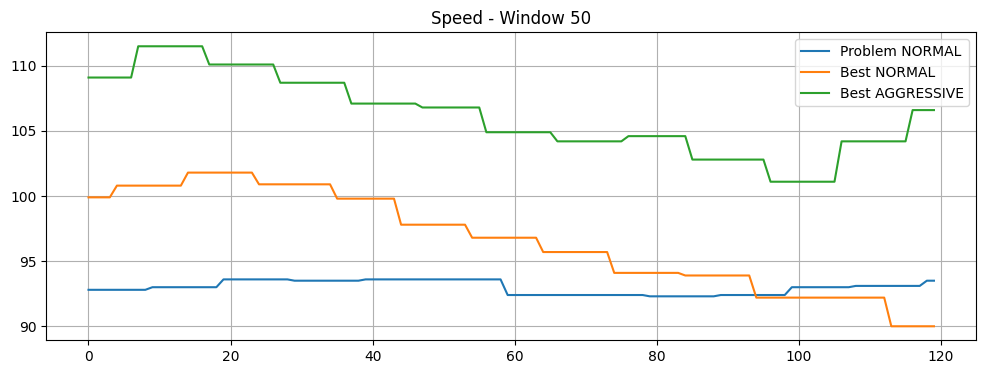

In [66]:
plt.figure(figsize=(12,4))

plt.plot(problem_X[50,:,6], label="Problem NORMAL")
plt.plot(normal_X[50,:,6], label="Best NORMAL")
plt.plot(aggressive_X[50,:,6], label="Best AGGRESSIVE")

plt.legend()
plt.grid(True)
plt.title("Speed - Window 50")
plt.show()

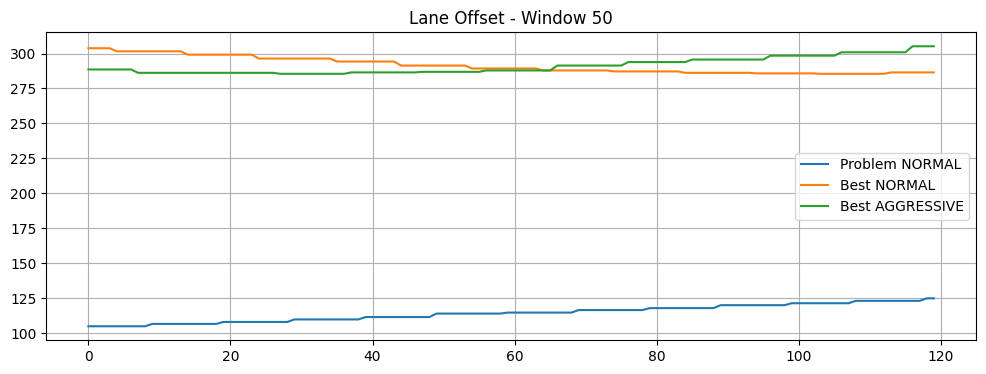

In [68]:
plt.figure(figsize=(12,4))

plt.plot(problem_X[50,:,7], label="Problem NORMAL")
plt.plot(normal_X[50,:,7], label="Best NORMAL")
plt.plot(aggressive_X[50,:,7], label="Best AGGRESSIVE")

plt.grid(True)
plt.legend()
plt.title("Lane Offset - Window 50")

plt.show()

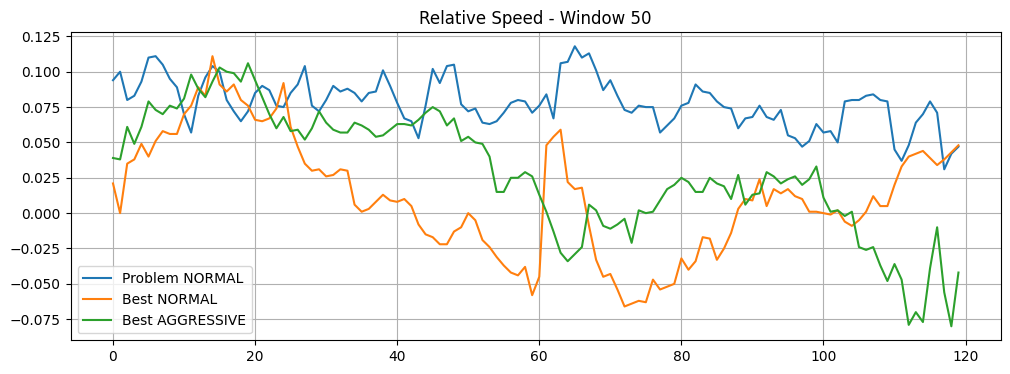

In [70]:
plt.figure(figsize=(12,4))

plt.plot(problem_X[50,:,9], label="Problem NORMAL")
plt.plot(normal_X[50,:,9], label="Best NORMAL")
plt.plot(aggressive_X[50,:,9], label="Best AGGRESSIVE")

plt.grid(True)
plt.legend()
plt.title("Relative Speed - Window 50")

plt.show()

In [72]:
import torch

problem_dataset = create_dataloader(
    problem_X,
    y[problem_idx],
    batch_size=32,
    shuffle=False,
)

model.eval()

window_preds = []
window_probs = []

with torch.no_grad():

    for sensor_batch, _ in problem_dataset:

        sensor_batch = sensor_batch.to(device)

        outputs = model(sensor_batch)

        probs = torch.softmax(outputs, dim=1)

        preds = probs.argmax(dim=1)

        window_preds.extend(preds.cpu().numpy())
        window_probs.extend(probs.cpu().numpy())

In [73]:
from collections import Counter

Counter(window_preds)

Counter({np.int64(2): 614, np.int64(0): 27})

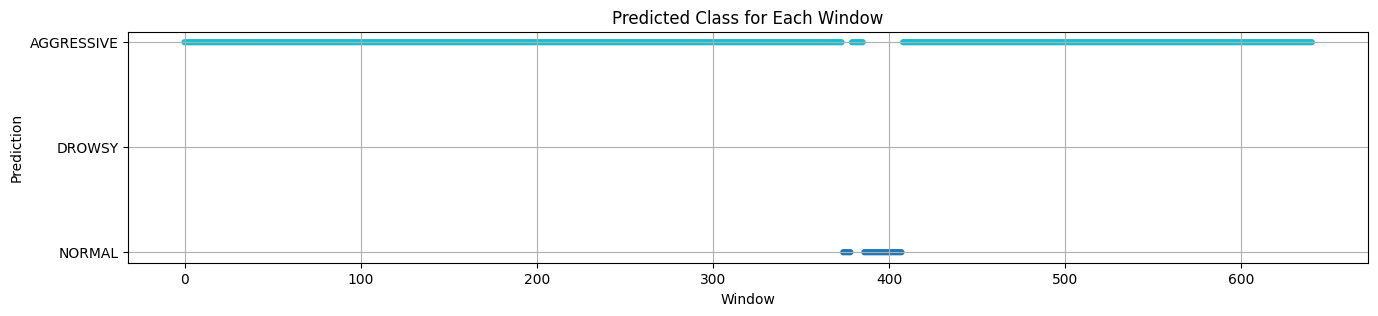

In [74]:
label_names = {
    0:"NORMAL",
    1:"DROWSY",
    2:"AGGRESSIVE",
}

plt.figure(figsize=(16,3))

plt.scatter(
    range(len(window_preds)),
    window_preds,
    c=window_preds,
    cmap="tab10",
    s=12,
)

plt.yticks(
    [0,1,2],
    ["NORMAL","DROWSY","AGGRESSIVE"]
)

plt.xlabel("Window")

plt.ylabel("Prediction")

plt.title("Predicted Class for Each Window")

plt.grid(True)

plt.show()

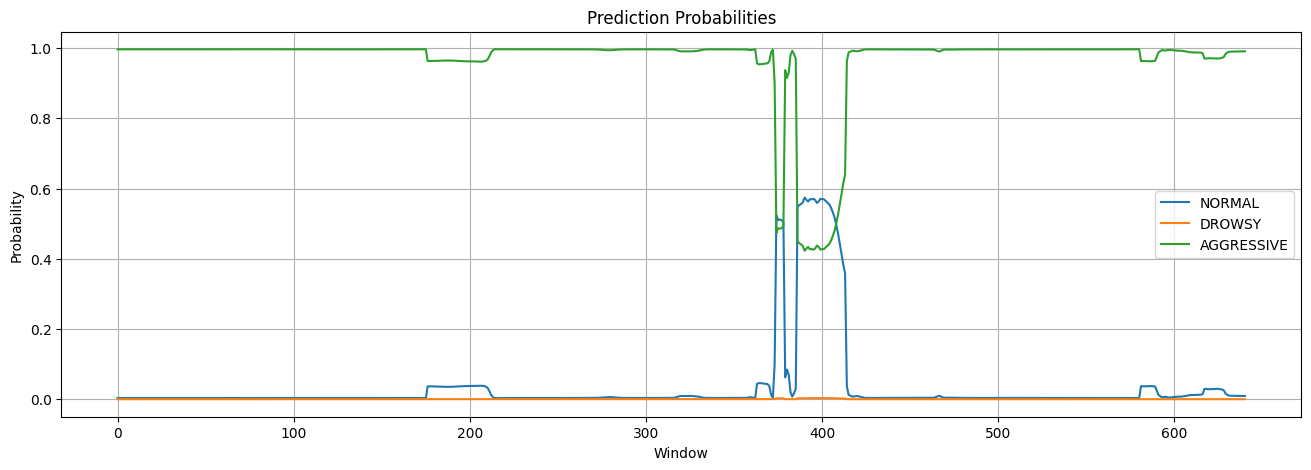

In [75]:
window_probs = np.array(window_probs)

plt.figure(figsize=(16,5))

plt.plot(window_probs[:,0], label="NORMAL")
plt.plot(window_probs[:,1], label="DROWSY")
plt.plot(window_probs[:,2], label="AGGRESSIVE")

plt.legend()

plt.grid(True)

plt.xlabel("Window")

plt.ylabel("Probability")

plt.title("Prediction Probabilities")

plt.show()

In [76]:
normal_windows = np.where(np.array(window_preds) == 0)[0]

print(normal_windows)

[374 375 376 377 378 386 387 388 389 390 391 392 393 394 395 396 397 398
 399 400 401 402 403 404 405 406 407]


In [77]:
lane_change_counts = []

for trip in range(40):

    trip_x = X[groups == trip]

    lane = trip_x[:, :, 7].reshape(-1)   # lane_offset

    diff = np.abs(np.diff(lane))

    lane_changes = np.sum(diff > 5)

    lane_change_counts.append(lane_changes)

lane_df = pd.DataFrame({
    "Trip": np.arange(1, 41),
    "Behavior": [label_map[l] for l in trip_labels],
    "Accuracy": fold_accuracies,
    "LaneChanges": lane_change_counts
})

lane_df.sort_values("LaneChanges", ascending=False)

,Trip,Behavior,Accuracy,LaneChanges
20,21,AGGRESSIVE,0.472087,728
8,9,AGGRESSIVE,0.771295,696
27,28,DROWSY,0.551690,683
14,15,NORMAL,0.619798,676
29,30,AGGRESSIVE,0.922194,670
25,26,NORMAL,0.542683,669
35,36,NORMAL,0.385686,661
15,16,DROWSY,0.683582,660
9,10,DROWSY,0.332255,651
30,31,DROWSY,0.407477,641


In [78]:
lane_df.sort_values("Accuracy")

,Trip,Behavior,Accuracy,LaneChanges
1,2,NORMAL,0.073323,427
9,10,DROWSY,0.332255,651
35,36,NORMAL,0.385686,661
30,31,DROWSY,0.407477,641
17,18,NORMAL,0.442922,503
13,14,DROWSY,0.464789,444
20,21,AGGRESSIVE,0.472087,728
28,29,NORMAL,0.488423,635
36,37,DROWSY,0.507109,561
7,8,NORMAL,0.518681,620


In [79]:
print(
    lane_df[["LaneChanges","Accuracy"]].corr()
)

             LaneChanges  Accuracy
LaneChanges      1.00000  -0.43738
Accuracy        -0.43738   1.00000


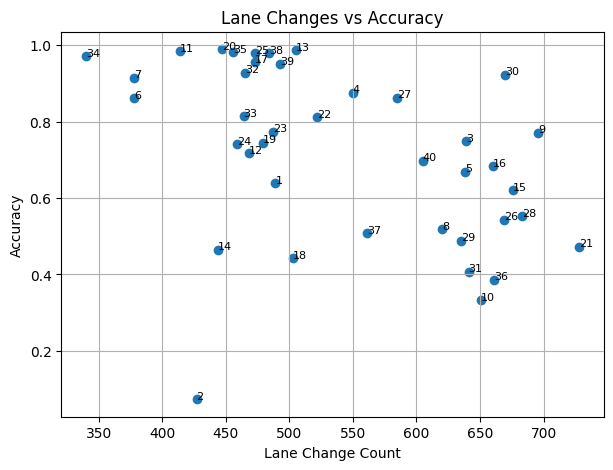

In [80]:
plt.figure(figsize=(7,5))

plt.scatter(
    lane_df["LaneChanges"],
    lane_df["Accuracy"],
)

for _, row in lane_df.iterrows():

    plt.text(
        row["LaneChanges"],
        row["Accuracy"],
        str(int(row["Trip"])),
        fontsize=8
    )

plt.xlabel("Lane Change Count")
plt.ylabel("Accuracy")
plt.title("Lane Changes vs Accuracy")

plt.grid(True)
plt.show()

In [81]:
problem_probs = window_probs[:,2]   # AGGRESSIVE olasılığı

In [82]:
problem_speed = problem_X[:,:,6].mean(axis=1)
normal_speed  = normal_X[:,:,6].mean(axis=1)

In [83]:
problem_lane = problem_X[:,:,7].mean(axis=1)
normal_lane  = normal_X[:,:,7].mean(axis=1)

In [84]:
problem_rel = problem_X[:,:,9].mean(axis=1)
normal_rel  = normal_X[:,:,9].mean(axis=1)

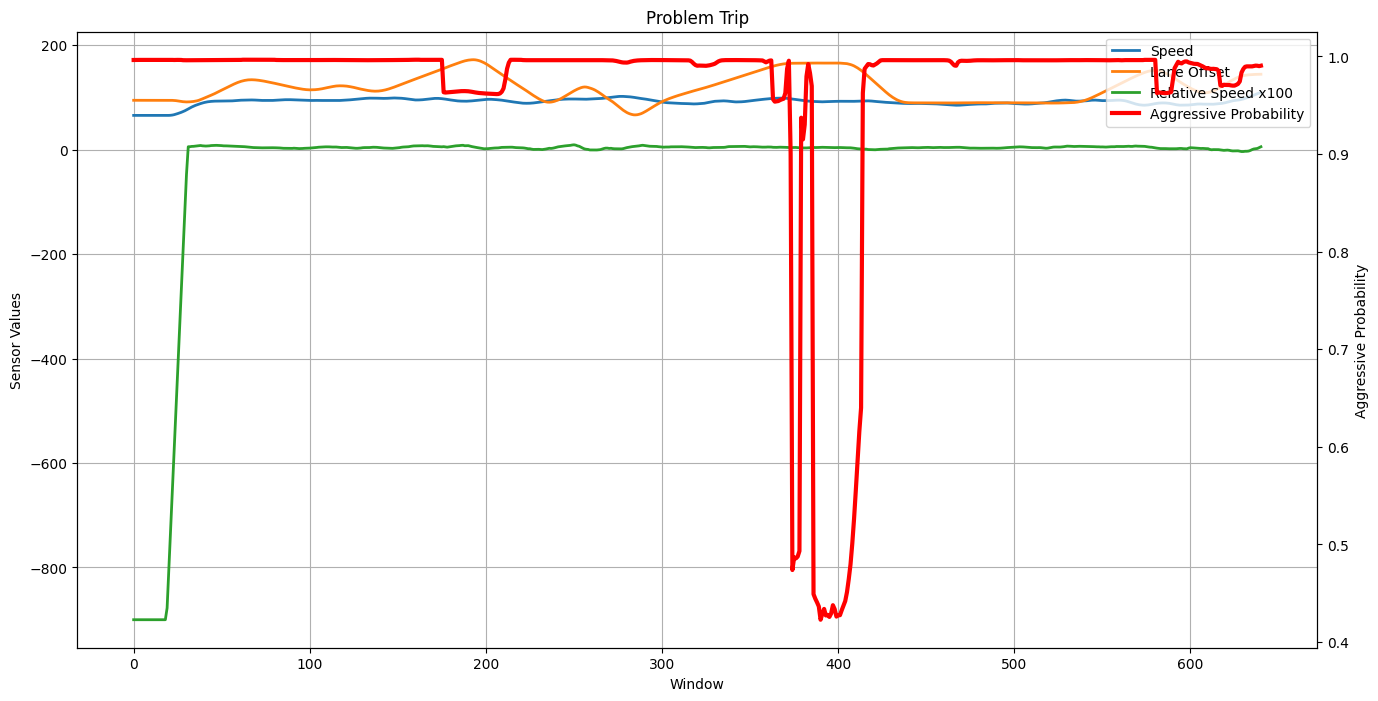

In [85]:
fig, ax = plt.subplots(figsize=(16,8))

x = np.arange(len(problem_probs))

# Problem video
ax.plot(x,
        problem_speed,
        label="Speed",
        linewidth=2)

ax.plot(x,
        problem_lane,
        label="Lane Offset",
        linewidth=2)

ax.plot(x,
        problem_rel*100,
        label="Relative Speed x100",
        linewidth=2)

ax2 = ax.twinx()

ax2.plot(
    x,
    problem_probs,
    color="red",
    linewidth=3,
    label="Aggressive Probability"
)

ax.set_xlabel("Window")
ax.set_ylabel("Sensor Values")
ax2.set_ylabel("Aggressive Probability")

ax.grid(True)

lines1, labels1 = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()

ax.legend(lines1+lines2,
          labels1+labels2,
          loc="upper right")

plt.title("Problem Trip")

plt.show()

In [88]:
problem_vec = problem_X.mean(axis=0).reshape(-1)
normal_vec = normal_X.mean(axis=0).reshape(-1)
aggressive_vec = aggressive_X.mean(axis=0).reshape(-1)

print(problem_vec.shape)

(1560,)


In [89]:
from sklearn.metrics.pairwise import cosine_similarity

sim_problem_normal = cosine_similarity(
    problem_vec.reshape(1,-1),
    normal_vec.reshape(1,-1)
)[0,0]

sim_problem_aggressive = cosine_similarity(
    problem_vec.reshape(1,-1),
    aggressive_vec.reshape(1,-1)
)[0,0]

print("Problem ↔ Normal      :", sim_problem_normal)
print("Problem ↔ Aggressive  :", sim_problem_aggressive)

Problem ↔ Normal      : 0.9288033932647396
Problem ↔ Aggressive  : 0.940290000927261


In [90]:
sim_normal_aggressive = cosine_similarity(
    normal_vec.reshape(1,-1),
    aggressive_vec.reshape(1,-1)
)[0,0]

print("Normal ↔ Aggressive :", sim_normal_aggressive)

Normal ↔ Aggressive : 0.9992156822356045


In [91]:
print(problem_X.shape)
print(len(window_preds))

(641, 120, 13)
641


In [92]:
video_duration = 438  # saniye

window_times = np.linspace(
    0,
    video_duration,
    len(window_preds)
)

print(window_times[370])
print(window_times[410])

253.21874999999997
280.59375


In [93]:
before = problem_X[:350]
during = problem_X[370:410]

before_mean = before.mean(axis=(0,1))
during_mean = during.mean(axis=(0,1))

comparison = pd.DataFrame({
    "Feature": feature_names,
    "Before": before_mean,
    "During": during_mean,
})

comparison

,Feature,Before,During
0,acc_x,-0.012736,-0.012341
1,acc_y,0.000935,-0.004284
2,acc_z,-0.005159,0.001240
3,roll,-1.574759,-1.523623
4,pitch,-0.006803,-0.038270
5,yaw,-2.279463,-1.656407
6,speed,92.003336,93.577458
7,lane_offset,117.094712,165.346229
8,front_distance,-0.463719,0.268186
9,relative_speed,-0.604746,0.040005


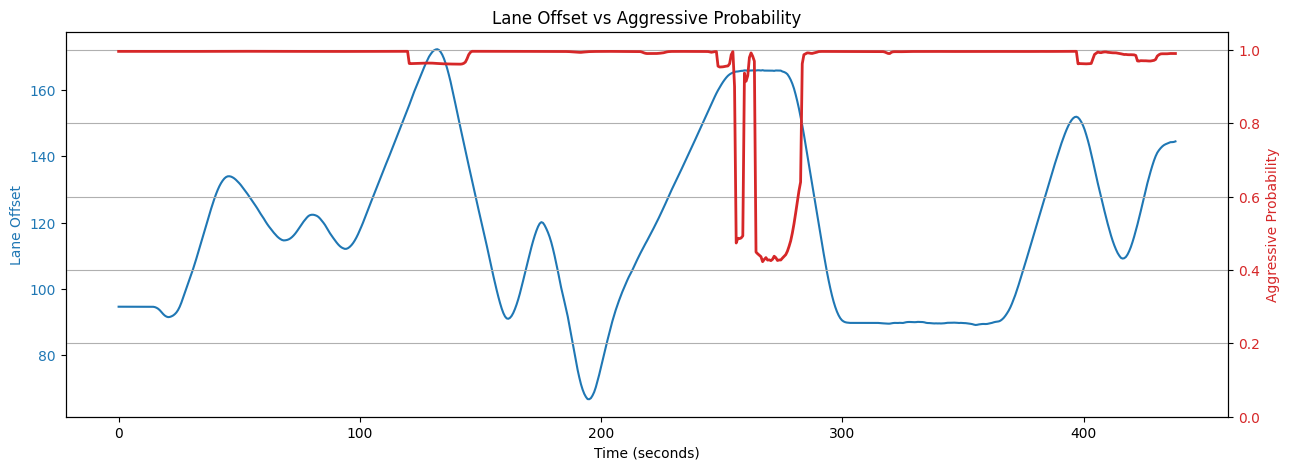

In [94]:
time = np.linspace(0, 438, len(window_probs))

lane = problem_X[:, :, 7].mean(axis=1)

aggressive_prob = window_probs[:, 2]

fig, ax1 = plt.subplots(figsize=(15,5))

ax1.plot(
    time,
    lane,
    color="tab:blue",
    label="Lane Offset"
)

ax1.set_xlabel("Time (seconds)")
ax1.set_ylabel("Lane Offset", color="tab:blue")
ax1.tick_params(axis="y", labelcolor="tab:blue")

ax2 = ax1.twinx()

ax2.plot(
    time,
    aggressive_prob,
    color="tab:red",
    linewidth=2,
    label="Aggressive Probability"
)

ax2.set_ylabel("Aggressive Probability", color="tab:red")
ax2.tick_params(axis="y", labelcolor="tab:red")
ax2.set_ylim(0,1.05)

plt.title("Lane Offset vs Aggressive Probability")
plt.grid(True)

plt.show()

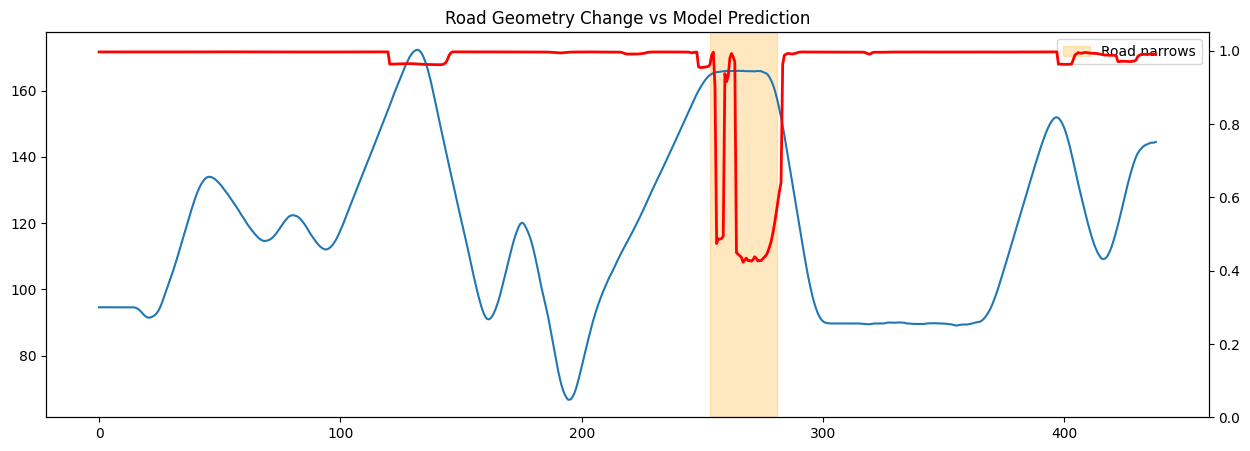

In [95]:
fig, ax1 = plt.subplots(figsize=(15,5))

ax1.plot(time, lane, color="tab:blue")

ax1.axvspan(
    253,
    281,
    color="orange",
    alpha=0.25,
    label="Road narrows"
)

ax2 = ax1.twinx()

ax2.plot(
    time,
    aggressive_prob,
    color="red",
    linewidth=2
)

ax2.set_ylim(0,1.05)

plt.title("Road Geometry Change vs Model Prediction")

ax1.legend()

plt.show()

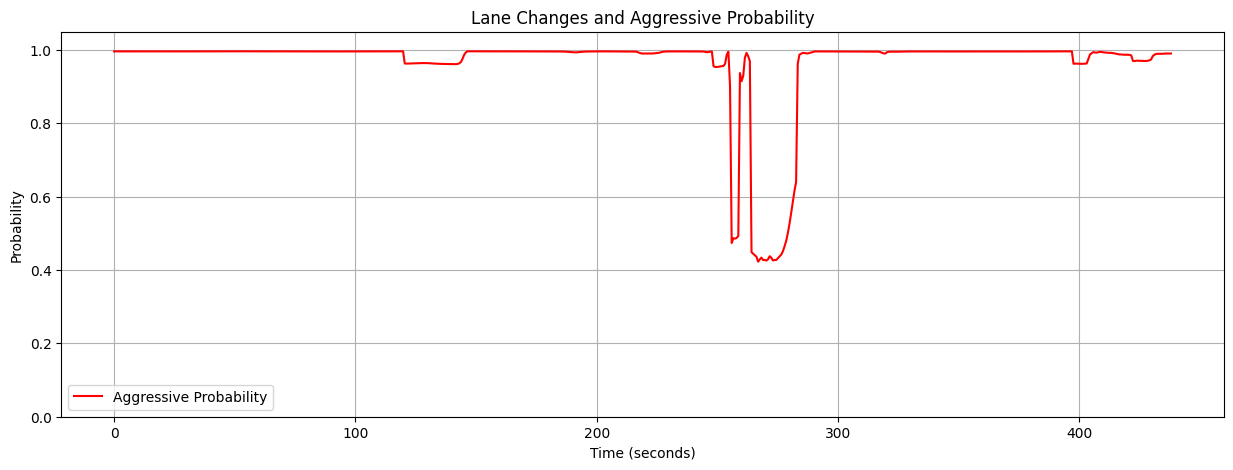

In [96]:
lane = problem_X[:, :, 7].mean(axis=1)

diff = np.abs(np.diff(lane))

change_idx = np.where(diff > 5)[0]

plt.figure(figsize=(15,5))

plt.plot(
    time,
    aggressive_prob,
    color="red",
    label="Aggressive Probability"
)

for idx in change_idx:
    plt.axvline(
        time[idx],
        color="blue",
        alpha=0.15
    )

plt.ylim(0,1.05)

plt.xlabel("Time (seconds)")
plt.ylabel("Probability")

plt.title("Lane Changes and Aggressive Probability")

plt.grid(True)

plt.legend()

plt.show()

In [97]:
features = {
    "speed": problem_X[:,:,6].mean(axis=1),
    "lane_offset": problem_X[:,:,7].mean(axis=1),
    "front_distance": problem_X[:,:,8].mean(axis=1),
    "relative_speed": problem_X[:,:,9].mean(axis=1),
}

for name, values in features.items():
    corr = np.corrcoef(values, aggressive_prob)[0,1]
    print(name, corr)

speed -0.05580377194039547
lane_offset -0.4526915425675734
front_distance -0.05911582172147191
relative_speed -0.05719506023155707


In [98]:
confidence = aggressive_prob

top = np.argsort(confidence)[-10:]
bottom = np.argsort(confidence)[:10]

print("Most aggressive windows")
print(top)

print()

print("Least aggressive windows")
print(bottom)

Most aggressive windows
[ 66  64  67  65  68  63 160 162 161 159]

Least aggressive windows
[390 395 399 393 401 400 394 391 396 402]


In [99]:
for idx in bottom:
    print(
        idx,
        f"{window_times[idx]:.1f} sec",
        aggressive_prob[idx]
    )

390 266.9 sec 0.42285448
395 270.3 sec 0.42570004
399 273.1 sec 0.4260555
393 269.0 sec 0.42721814
401 274.4 sec 0.4274465
400 273.8 sec 0.42753547
394 269.6 sec 0.427821
391 267.6 sec 0.42896634
396 271.0 sec 0.42923588
402 275.1 sec 0.4325487


In [100]:
for idx in bottom:
    print(
        idx,
        np.argmax(window_probs[idx]),
        window_probs[idx]
    )

390 0 [0.5741972  0.00294834 0.42285448]
395 0 [0.57101876 0.0032812  0.42570004]
399 0 [0.57102066 0.00292379 0.4260555 ]
393 0 [0.56972176 0.00306017 0.42721814]
401 0 [0.56952167 0.00303175 0.4274465 ]
400 0 [0.569474   0.00299051 0.42753547]
394 0 [0.569075   0.00310395 0.427821  ]
391 0 [0.5679737  0.00305994 0.42896634]
396 0 [0.5674272  0.00333694 0.42923588]
402 0 [0.5644176  0.00303369 0.4325487 ]


In [101]:
start = 360
end = 420

for idx in range(start, end + 1):
    print(
        f"{idx:3d}",
        f"{window_times[idx]:6.1f} s",
        np.argmax(window_probs[idx]),
        np.round(window_probs[idx], 3)
    )

360  246.4 s 2 [0.005 0.    0.995]
361  247.1 s 2 [0.004 0.    0.996]
362  247.7 s 2 [0.004 0.    0.996]
363  248.4 s 2 [0.044 0.    0.956]
364  249.1 s 2 [0.046 0.    0.954]
365  249.8 s 2 [0.046 0.    0.954]
366  250.5 s 2 [0.045 0.    0.954]
367  251.2 s 2 [0.045 0.    0.955]
368  251.8 s 2 [0.044 0.    0.956]
369  252.5 s 2 [0.043 0.    0.957]
370  253.2 s 2 [0.037 0.    0.963]
371  253.9 s 2 [0.012 0.    0.987]
372  254.6 s 2 [0.004 0.    0.996]
373  255.3 s 2 [0.099 0.    0.901]
374  256.0 s 0 [0.523 0.003 0.474]
375  256.6 s 0 [0.511 0.003 0.487]
376  257.3 s 0 [0.512 0.003 0.486]
377  258.0 s 0 [0.51  0.003 0.488]
378  258.7 s 0 [0.504 0.002 0.493]
379  259.4 s 2 [0.062 0.    0.937]
380  260.1 s 2 [0.085 0.    0.915]
381  260.7 s 2 [0.07 0.   0.93]
382  261.4 s 2 [0.02 0.   0.98]
383  262.1 s 2 [0.008 0.    0.992]
384  262.8 s 2 [0.017 0.    0.983]
385  263.5 s 2 [0.03 0.   0.97]
386  264.2 s 0 [0.548 0.003 0.449]
387  264.9 s 0 [0.553 0.003 0.444]
388  265.5 s 0 [0.556 0.003 0

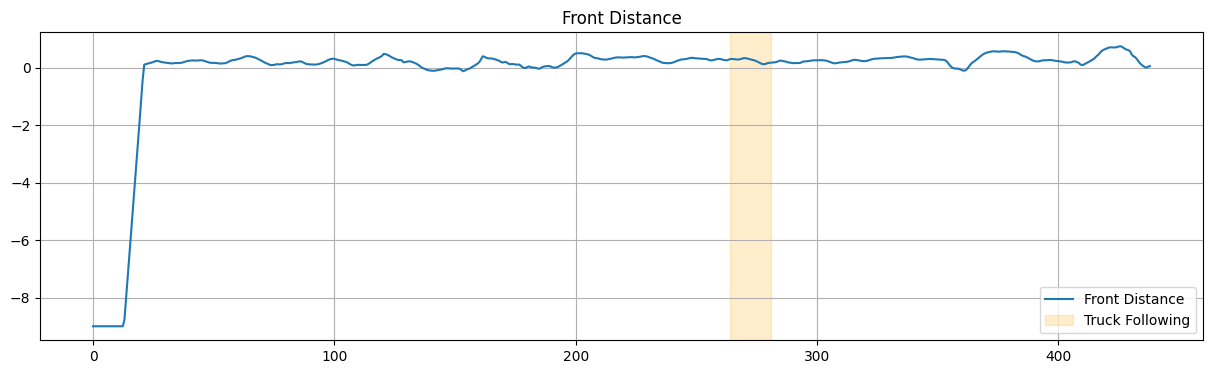

In [102]:
plt.figure(figsize=(15,4))

plt.plot(
    time,
    problem_X[:,:,8].mean(axis=1),
    label="Front Distance"
)

plt.axvspan(264,281,color="orange",alpha=0.2,label="Truck Following")

plt.grid(True)
plt.legend()
plt.title("Front Distance")
plt.show()

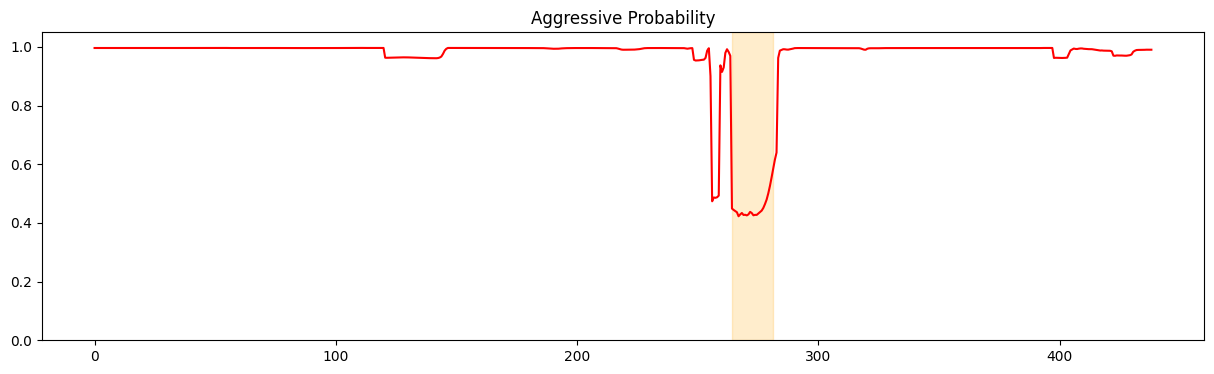

In [103]:
plt.figure(figsize=(15,4))

plt.plot(
    time,
    aggressive_prob,
    color="red"
)

plt.axvspan(264,281,color="orange",alpha=0.2)

plt.ylim(0,1.05)

plt.title("Aggressive Probability")
plt.show()

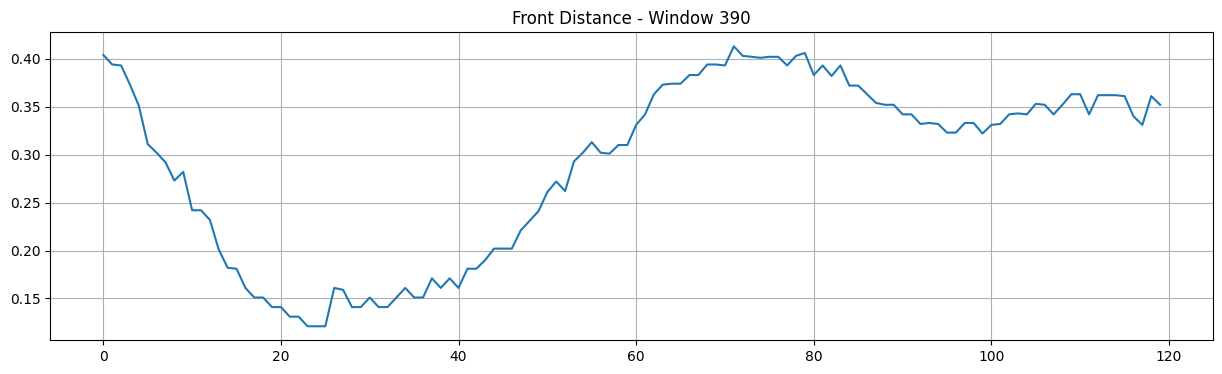

In [104]:
window = 390

plt.figure(figsize=(15,4))

plt.plot(problem_X[window,:,8])

plt.title("Front Distance - Window 390")

plt.grid(True)

plt.show()

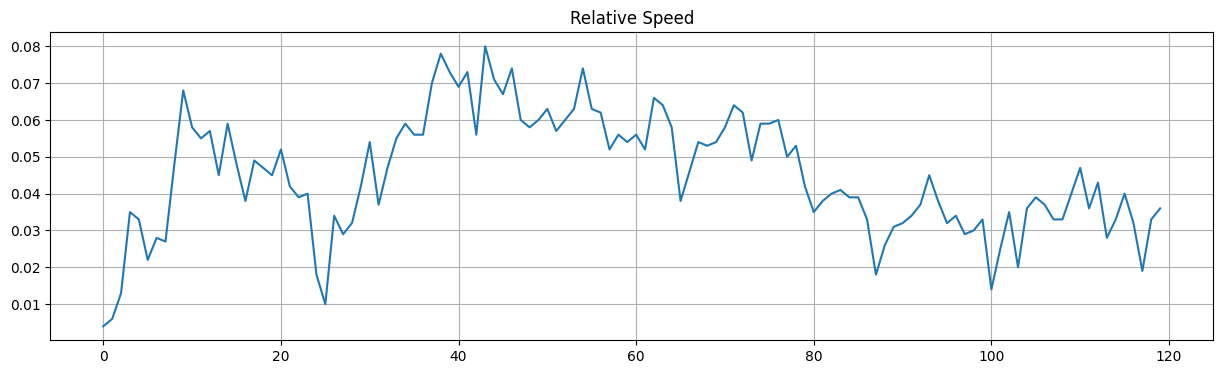

In [105]:
plt.figure(figsize=(15,4))

plt.plot(problem_X[390,:,9])

plt.grid(True)

plt.title("Relative Speed")

plt.show()

In [106]:
print("Original Mean Accuracy :", np.mean(fold_accuracies))

new_fold_accuracies = np.delete(fold_accuracies, 1)   # Trip 2 çıkarılıyor

print("Without Trip 2         :", np.mean(new_fold_accuracies))

print()
print("Difference :", np.mean(new_fold_accuracies) - np.mean(fold_accuracies))

Original Mean Accuracy : 0.7189181752831368
Without Trip 2         : 0.7354718994463629

Difference : 0.01655372416322609
